In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load Dataset

In [ ]:
data=pd.read_csv('/content/KaggleV2-May-2016.csv')
data.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
data.shape

(110527, 14)

In [ ]:

data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


# Data Cleaning

In [ ]:
print(data.isnull)
print(data.isnull().sum())

<bound method DataFrame.isnull of            PatientId  AppointmentID Gender          ScheduledDay  \
0       2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1       5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2       4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3       8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4       8.841186e+12        5642494      F  2016-04-29T16:07:23Z   
...              ...            ...    ...                   ...   
110522  2.572134e+12        5651768      F  2016-05-03T09:15:35Z   
110523  3.596266e+12        5650093      F  2016-05-03T07:27:33Z   
110524  1.557663e+13        5630692      F  2016-04-27T16:03:52Z   
110525  9.213493e+13        5630323      F  2016-04-27T15:09:23Z   
110526  3.775115e+14        5629448      F  2016-04-27T13:30:56Z   

              AppointmentDay  Age      Neighbourhood  Scholarship  \
0       2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0   
1       201

In [ ]:
print(data.duplicated().sum())

0


In [ ]:
data['Age'].describe()

,Age
count,110527.000000
mean,37.088874
std,23.110205
min,-1.000000
25%,18.000000
50%,37.000000
75%,55.000000
max,115.000000


In [ ]:
data=data[data['Age'] >=0]

In [ ]:
data['ScheduledDay'] = pd.to_datetime(data['ScheduledDay']).dt.normalize()
data['AppointmentDay'] = pd.to_datetime(data['AppointmentDay']).dt.normalize()

# Feature Eng.

In [ ]:
data['WaitingDay'] = (
    data['AppointmentDay'] - data['ScheduledDay']
).dt.days
data.WaitingDay

,WaitingDay
0,0
1,0
2,0
3,0
4,0
...,...
110522,35
110523,35
110524,41
110525,41


# EDA

In [ ]:
data['No-show'].value_counts()

,count
No-show,
No,88207
Yes,22319


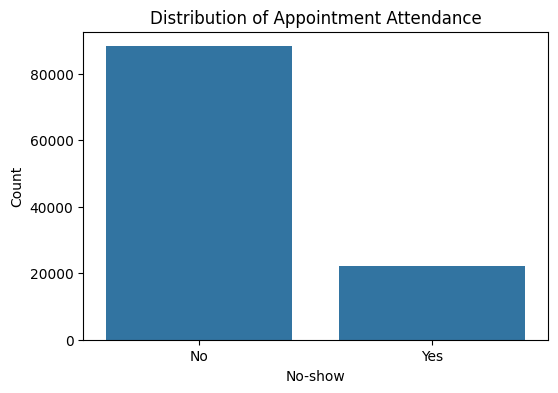

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='No-show', data=data)
plt.title("Distribution of Appointment Attendance")
plt.xlabel("No-show")
plt.ylabel("Count")
plt.show()

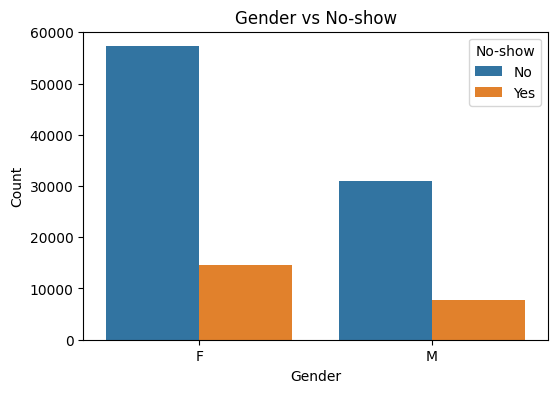

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='No-show', data=data)
plt.title('Gender vs No-show')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

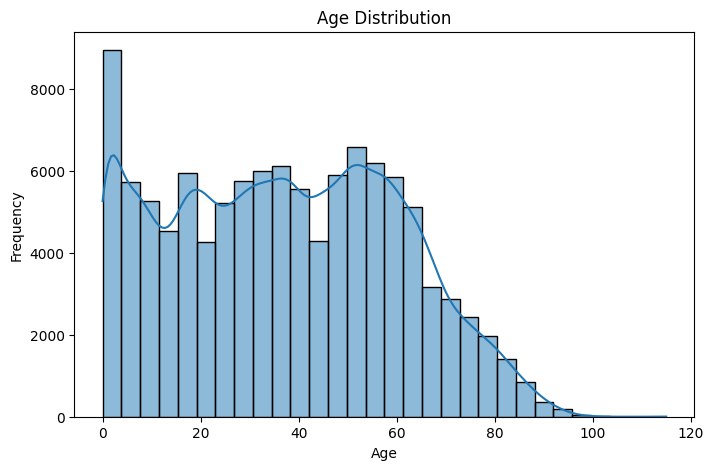

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

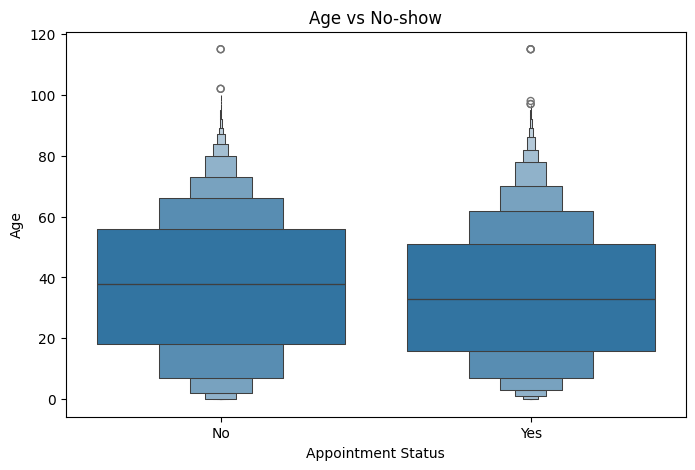

In [ ]:
plt.figure(figsize=(8,5))
sns.boxenplot(x='No-show', y='Age', data=data)
plt.title('Age vs No-show')
plt.xlabel('Appointment Status')
plt.ylabel('Age')
plt.show()

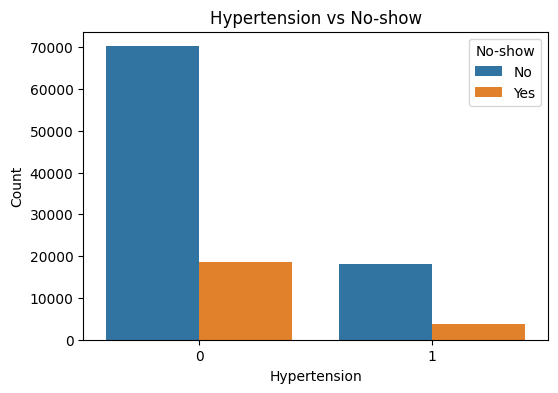

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Hipertension', hue='No-show', data=data)
plt.title('Hypertension vs No-show')
plt.xlabel('Hypertension')
plt.ylabel('Count')
plt.show()

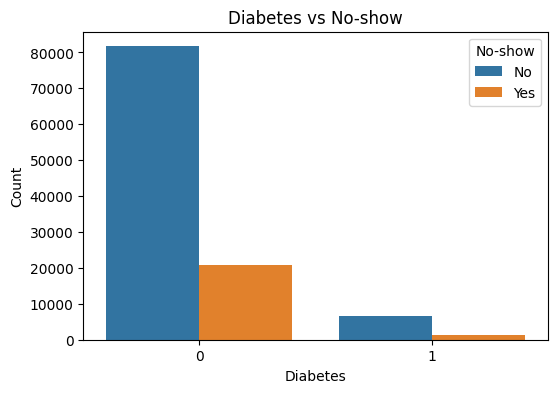

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Diabetes', hue='No-show', data=data)
plt.title('Diabetes vs No-show')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.show()

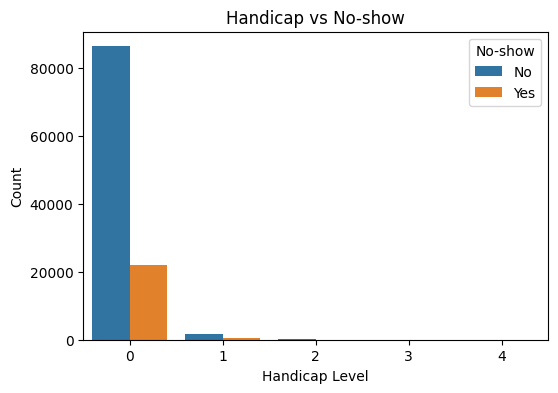

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Handcap', hue='No-show', data=data)
plt.title('Handicap vs No-show')
plt.xlabel('Handicap Level')
plt.ylabel('Count')
plt.show()

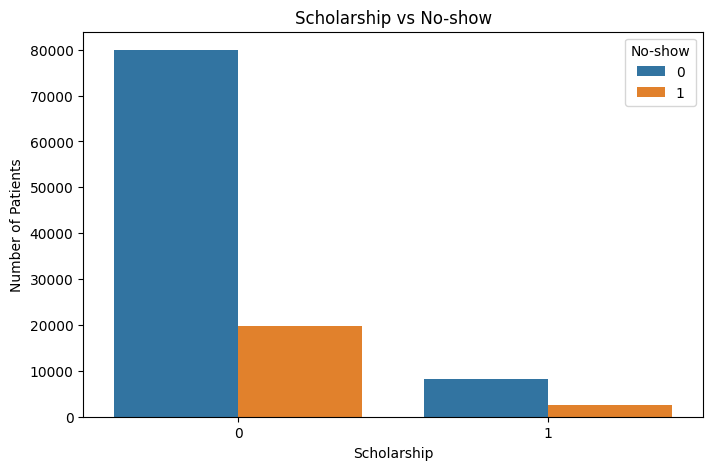

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Scholarship', hue='No-show', data=data)

plt.title('Scholarship vs No-show')
plt.xlabel('Scholarship')
plt.ylabel('Number of Patients')
plt.legend(title='No-show')

plt.show()

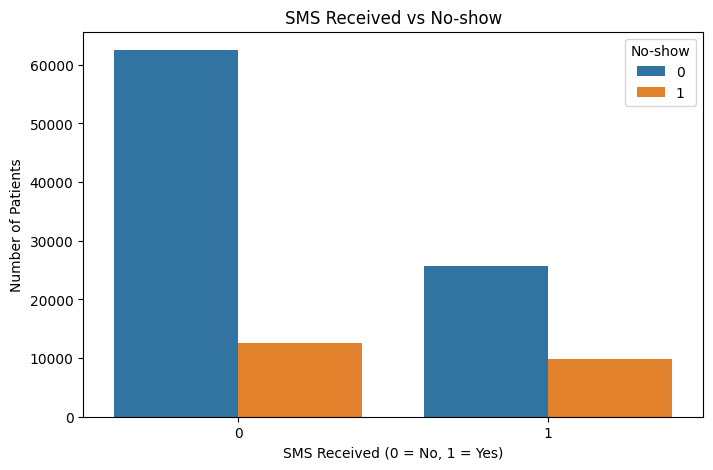

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='SMS_received', hue='No-show', data=data)

plt.title('SMS Received vs No-show')
plt.xlabel('SMS Received (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')

plt.show()

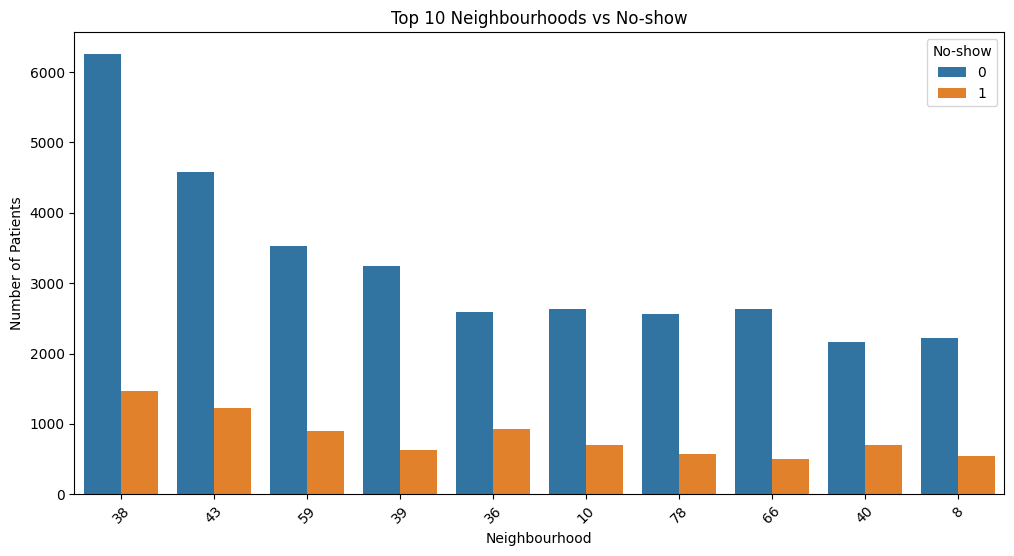

In [ ]:
# Top 10 neighbourhoods by number of appointments
top10 = data['Neighbourhood'].value_counts().head(10).index

# Filter dataset for top 10 neighbourhoods
top10_data = data[data['Neighbourhood'].isin(top10)]

# Plot
plt.figure(figsize=(12,6))

sns.countplot(
    data=top10_data,
    x='Neighbourhood',
    hue='No-show',
    order=top10
)

plt.title('Top 10 Neighbourhoods vs No-show')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='No-show')

plt.show()

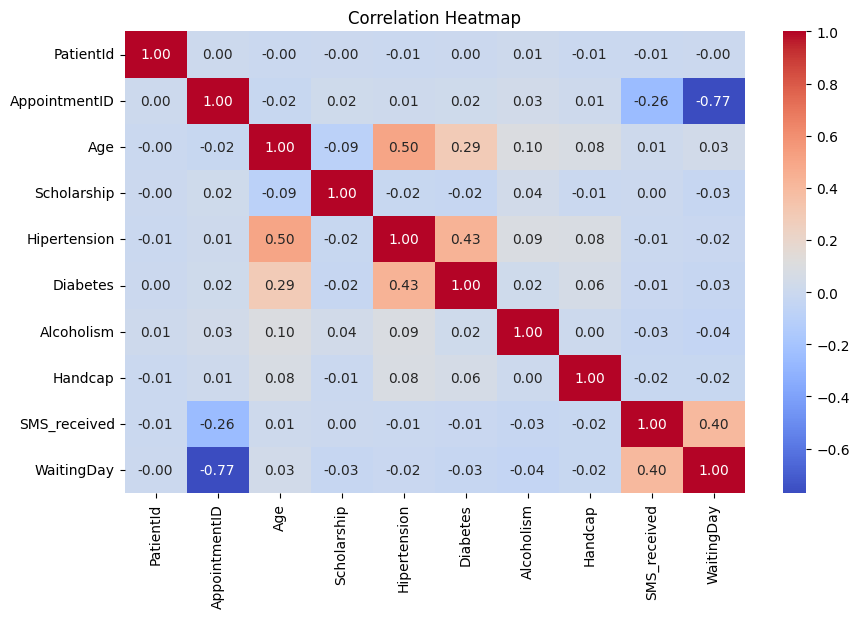

In [ ]:
plt.figure(figsize=(10,6))

numeric_data = data.select_dtypes(include=['number'])

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

# Preprocessing

Label encode

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Neighbourhood'] = label_encoder.fit_transform(data['Neighbourhood'])
data['No-show'] = label_encoder.fit_transform(data['No-show'])

drop cloums

In [ ]:
data = data.drop(['PatientId', 'AppointmentID'], axis=1)
data = data.drop(['ScheduledDay', 'AppointmentDay'], axis=1)

In [ ]:
# Features (Input)
X = data.drop('No-show', axis=1)

# Target (Output)
y = data['No-show']

# Train and test Spilt

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

# Train Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

**Logistc Regression**

In [ ]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_pred))

Accuracy: 0.573373744684701
Precision: 0.24175938442341688
Recall: 0.5208333333333334
F1 Score: 0.33023222782472833
ROC-AUC: 0.5537507557722103


**Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))
print("ROC-AUC:", roc_auc_score(y_test, dt_pred))

Accuracy: 0.6915769474350855
Precision: 0.30818122555410693
Recall: 0.4236111111111111
F1 Score: 0.3567924528301887
ROC-AUC: 0.5914960668354559


**Random** **Forest**

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_pred))

Accuracy: 0.6950149280738261
Precision: 0.3149171270718232
Recall: 0.43413978494623656
F1 Score: 0.36504049726878884
ROC-AUC: 0.5975823060316717


Results

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.573374,0.241759,0.520833,0.330232,0.553751
1,Decision Tree,0.691577,0.308181,0.423611,0.356792,0.591496
2,Random Forest,0.695015,0.314917,0.434140,0.365040,0.597582


         Feature  Importance
9     WaitingDay    0.327808
1            Age    0.297918
2  Neighbourhood    0.291631
0         Gender    0.024061
8   SMS_received    0.020002
4   Hipertension    0.014284
3    Scholarship    0.008993
5       Diabetes    0.006975
7        Handcap    0.004548
6     Alcoholism    0.003780


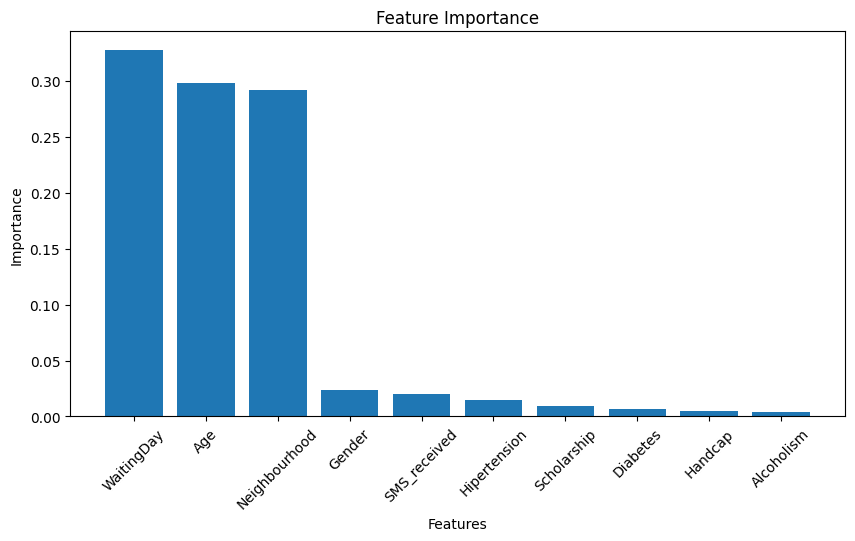

In [ ]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

plt.figure(figsize=(10,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

Confusion Matrix

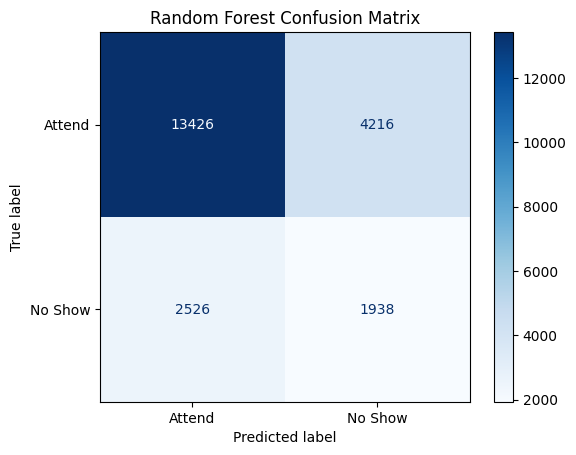

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, rf_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Attend", "No Show"])

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
patient_data = {
    "Gender": 1,
    "Age": 35,
    "Neighbourhood": 120,
    "Scholarship": 0,
    "Hipertension": 1,
    "Diabetes": 0,
    "Alcoholism": 0,
    "Handcap": 0,
    "SMS_received": 1,
    "WaitingDay": 5
}

patient = pd.DataFrame([patient_data])

rf_pred = rf.predict(patient)

rf_pred = rf.predict(patient)

if rf_pred[0] == 0:
    print(" The patient is likely to attend the appointment.")
else:
    print(" The patient is likely to miss the appointment.")